# 1. Import Libraries

In [1]:
!pip install opencv-python-headless matplotlib tqdm scikit-learn -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from collections import Counter
from sklearn.model_selection import train_test_split
import gc
from tqdm.notebook import tqdm

# 2. Unzip Dataset

In [2]:
!pip install kaggle -q

In [3]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_json = {
    "username": "salmaazoz",   # مش مهم قوي هنا
    "key": "KGAT_751e3fdaa20cfdae49cd33323dbc56c8"
}

import json

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

In [4]:
!kaggle datasets download -d orvile/brain-cancer-mri-dataset -p /content/

Dataset URL: https://www.kaggle.com/datasets/orvile/brain-cancer-mri-dataset
License(s): CC-BY-SA-4.0




  0%|          | 0.00/144M [00:00<?, ?B/s]
  1%|          | 1.00M/144M [00:00<01:57, 1.28MB/s]
  1%|▏         | 2.00M/144M [00:01<01:10, 2.12MB/s]
  2%|▏         | 3.00M/144M [00:01<01:05, 2.26MB/s]
  3%|▎         | 4.00M/144M [00:01<01:05, 2.25MB/s]
  3%|▎         | 5.00M/144M [00:02<01:03, 2.31MB/s]
  4%|▍         | 6.00M/144M [00:02<01:01, 2.36MB/s]
  5%|▍         | 7.00M/144M [00:03<00:57, 2.52MB/s]
  6%|▌         | 8.00M/144M [00:03<00:53, 2.65MB/s]
  6%|▌         | 9.00M/144M [00:03<00:52, 2.73MB/s]
  7%|▋         | 10.0M/144M [00:04<00:51, 2.75MB/s]
  8%|▊         | 11.0M/144M [00:04<00:48, 2.87MB/s]
  8%|▊         | 12.0M/144M [00:04<00:48, 2.87MB/s]
  9%|▉         | 13.0M/144M [00:05<00:53, 2.60MB/s]
 10%|▉         | 14.0M/144M [00:06<00:57, 2.37MB/s]
 10%|█         | 15.0M/144M [00:06<00:58, 2.34MB/s]
 11%|█         | 16.0M/144M [00:06<00:56, 2.38MB/s]
 12%|█▏        | 17.0M/144M [00:07<00:57, 2.31MB/s]
 12%|█▏        | 18.0M/144M [00:07<00:56, 2.37MB/s]
 13%|█▎        | 19.

In [5]:
import zipfile

zip_path = "/content/brain-cancer-mri-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("✅ Extraction done")

✅ Extraction done


In [6]:
import os

for root, dirs, files in os.walk("/content/data"):
    print(root, "→", len(files), "files")

/content/data → 1 files
/content/data\Brain_Cancer raw MRI data → 0 files
/content/data\Brain_Cancer raw MRI data\Brain_Cancer → 0 files
/content/data\Brain_Cancer raw MRI data\Brain_Cancer\brain_glioma → 2004 files
/content/data\Brain_Cancer raw MRI data\Brain_Cancer\brain_menin → 2004 files
/content/data\Brain_Cancer raw MRI data\Brain_Cancer\brain_tumor → 2048 files


# 3. Dataset Exploration & Class Discovery
- Dynamically explore folder structure.
- Auto-detect class folders (subdirs with >100 images).
- Expected: brain_glioma (2004), brain_menin (2004), brain_tumor (2048).
- Total: 6056 images (all 512x512x3 JPGs).

In [7]:
root_dir = '/content/data/'
print("\nExploring structure...")
!ls -la {root_dir}
!find {root_dir} -name "*.jpg" | head -5

classes = []
img_counts = {}
for root, dirs, files in os.walk(root_dir):
    for dir_name in dirs:
        dir_path = os.path.join(root, dir_name)
        jpg_count = len(glob(os.path.join(dir_path, '*.jpg'))) + len(glob(os.path.join(dir_path, '*.png')))
        png_count = len(glob(os.path.join(dir_path, '*.JPG'))) + len(glob(os.path.join(dir_path, '*.PNG')))
        total = jpg_count + png_count
        if total > 100:
            classes.append(dir_name)
            img_counts[dir_name] = total
            print(f"Found class '{dir_name}' in '{root}': {total} images")

classes = list(img_counts.keys())
classes.sort()
print(f"\nDiscovered classes: {classes}")
print(f"Total images: {sum(img_counts.values())} (expected ~6056)")


Exploring structure...


'ls' is not recognized as an internal or external command,
operable program or batch file.


Found class 'brain_glioma' in '/content/data/Brain_Cancer raw MRI data\Brain_Cancer': 4008 images
Found class 'brain_menin' in '/content/data/Brain_Cancer raw MRI data\Brain_Cancer': 4008 images
Found class 'brain_tumor' in '/content/data/Brain_Cancer raw MRI data\Brain_Cancer': 4096 images

Discovered classes: ['brain_glioma', 'brain_menin', 'brain_tumor']
Total images: 12112 (expected ~6056)


'head' is not recognized as an internal or external command,
operable program or batch file.


# 4. Raw Data Verification Plots
- Sample sizes confirmation (all 512x512 ✓).
- Raw grayscale sample images per class → `raw_verify.png`.

In [8]:
data_dir = os.path.join(root_dir, classes[0].split('/')[0]) if '/' in classes[0] else root_dir
sizes = []
sample_paths = {}
for cls in classes[:3]:
    cls_paths = glob(f"{root_dir}**/{cls}/*.jpg", recursive=True)
    if cls_paths:
        sample_paths[cls] = cls_paths[0]
        for path in cls_paths[:5]:
            img = cv2.imread(path)
            if img is not None:
                h, w, c = img.shape
                sizes.append((h, w, c, cls))

print("\nSample sizes:", dict(Counter([(h,w,c) for h,w,c,_ in sizes])))
print("Expected: 512x512x3 ✓")


Sample sizes: {(512, 512, 3): 15}
Expected: 512x512x3 ✓


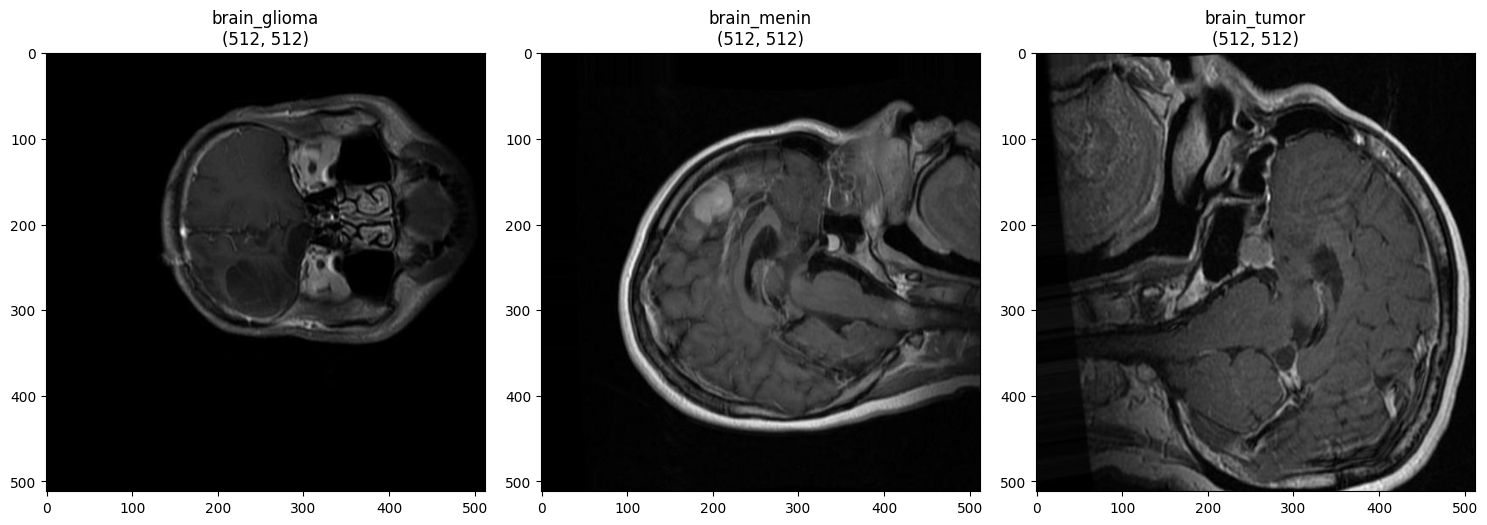


Verified! Classes: ['brain_glioma', 'brain_menin', 'brain_tumor']
data_dir for preprocessing: /content/data/
Use this output for team! → Proceed to preprocessing.


In [9]:
fig, axs = plt.subplots(1, min(3, len(classes)), figsize=(5*min(3,len(classes)), 5))
if len(classes) == 1: axs = [axs]
for i, cls in enumerate(classes[:3]):
    path = sample_paths.get(cls)
    if path:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axs[i].imshow(img, cmap='gray')
        axs[i].set_title(f'{cls}\n{img.shape}')
plt.tight_layout()
plt.savefig('raw_verify.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVerified! Classes: {classes}")
print("data_dir for preprocessing:", data_dir)
print("Use this output for team! → Proceed to preprocessing.")

# 5. Train/Test Split Preparation
- Load all image paths recursively.
- Stratified 80/20 split (random_state=42 → reproducible).
- Balance preserved: Train ~4844, Test ~1212.

In [10]:
def load_raw_paths(root_dir, classes):
    all_paths, all_labels = [], []
    for cls in classes:
        cls_paths = (glob(f"{root_dir}**/{cls}/*.jpg", recursive=True) +
                     glob(f"{root_dir}**/{cls}/*.png", recursive=True) +
                     glob(f"{root_dir}**/{cls}/*.JPG", recursive=True))
        all_paths.extend(cls_paths)
        all_labels.extend([class_map[cls]] * len(cls_paths))
    return np.array(all_paths), np.array(all_labels)

class_map = {cls_name: i for i, cls_name in enumerate(classes)}
print(f"Class mapping: {class_map}")

all_paths, all_y = load_raw_paths(root_dir, classes)
print(f"All paths: {len(all_paths)}, balance: {np.bincount(all_y)}")

paths_train, paths_test, y_train, y_test = train_test_split(
    all_paths, all_y, test_size=0.2, stratify=all_y, random_state=42
)


Class mapping: {'brain_glioma': 0, 'brain_menin': 1, 'brain_tumor': 2}
All paths: 12112, balance: [4008 4008 4096]


# 6. Preprocessing Functions
- **Original**: Grayscale → Resize 128x128 (Lanczos) → Normalize [0,1].
- **Enhanced**: Original + MedianBlur(3 denoise) + CLAHE(2.0 contrast).
- Recursive glob for samples.
- Verify: Raw (512,512,3) → Processed (128,128) [0.0-1.0].
- **Side-by-side**: Raw RGB vs Processed grayscale → `raw_vs_processed.png`.

Test preprocess:
brain_glioma: Raw (512, 512, 3) → Processed (128, 128) [0.000-0.831]


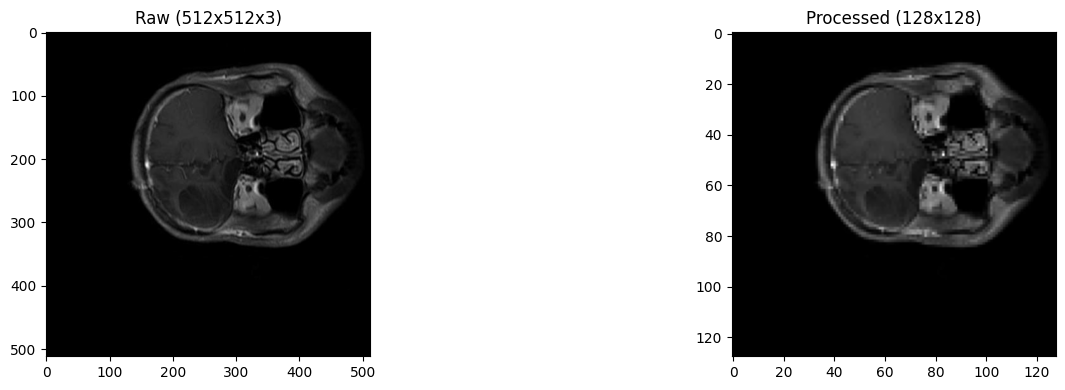

In [11]:
def preprocess_image(img_path, size=(128, 128)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, size, interpolation=cv2.INTER_LANCZOS4)
    img = img.astype(np.float32) / 255.0
    return img


print("Test preprocess:")
sample_paths = {}
for cls in classes:
    cls_paths = glob(f"{root_dir}**/{cls}/*.jpg", recursive=True) + glob(f"{root_dir}**/{cls}/*.png", recursive=True)
    if cls_paths:
        sample_paths[cls] = cls_paths[0]
        proc_img = preprocess_image(sample_paths[cls])
        if proc_img is not None:
            print(f"{cls}: Raw {cv2.imread(sample_paths[cls]).shape} → Processed {proc_img.shape} [{proc_img.min():.3f}-{proc_img.max():.3f}]")
            break


fig, axs = plt.subplots(1, 2, figsize=(16, 4))
raw_img = cv2.imread(list(sample_paths.values())[0])
axs[0].imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
axs[0].set_title('Raw (512x512x3)')
proc_img = preprocess_image(list(sample_paths.values())[0])
axs[1].imshow(proc_img, cmap='gray')
axs[1].set_title('Processed (128x128)')
plt.tight_layout()
plt.savefig('raw_vs_processed.png', dpi=150)
plt.show()


In [12]:
def preprocess_image_enhanced(img_path, size=(128, 128)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img_denoised = cv2.medianBlur(img, 3)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img_denoised)
    img_resized = cv2.resize(img_clahe, size, interpolation=cv2.INTER_LANCZOS4)
    img = img_resized.astype(np.float32) / 255.0
    return img

# 7. CLAHE+Denoise Test (5 Samples)
Visual comparison: Original vs Enhanced → `clahe_test.png`.
Expect: Sharper tumors, higher local contrast.

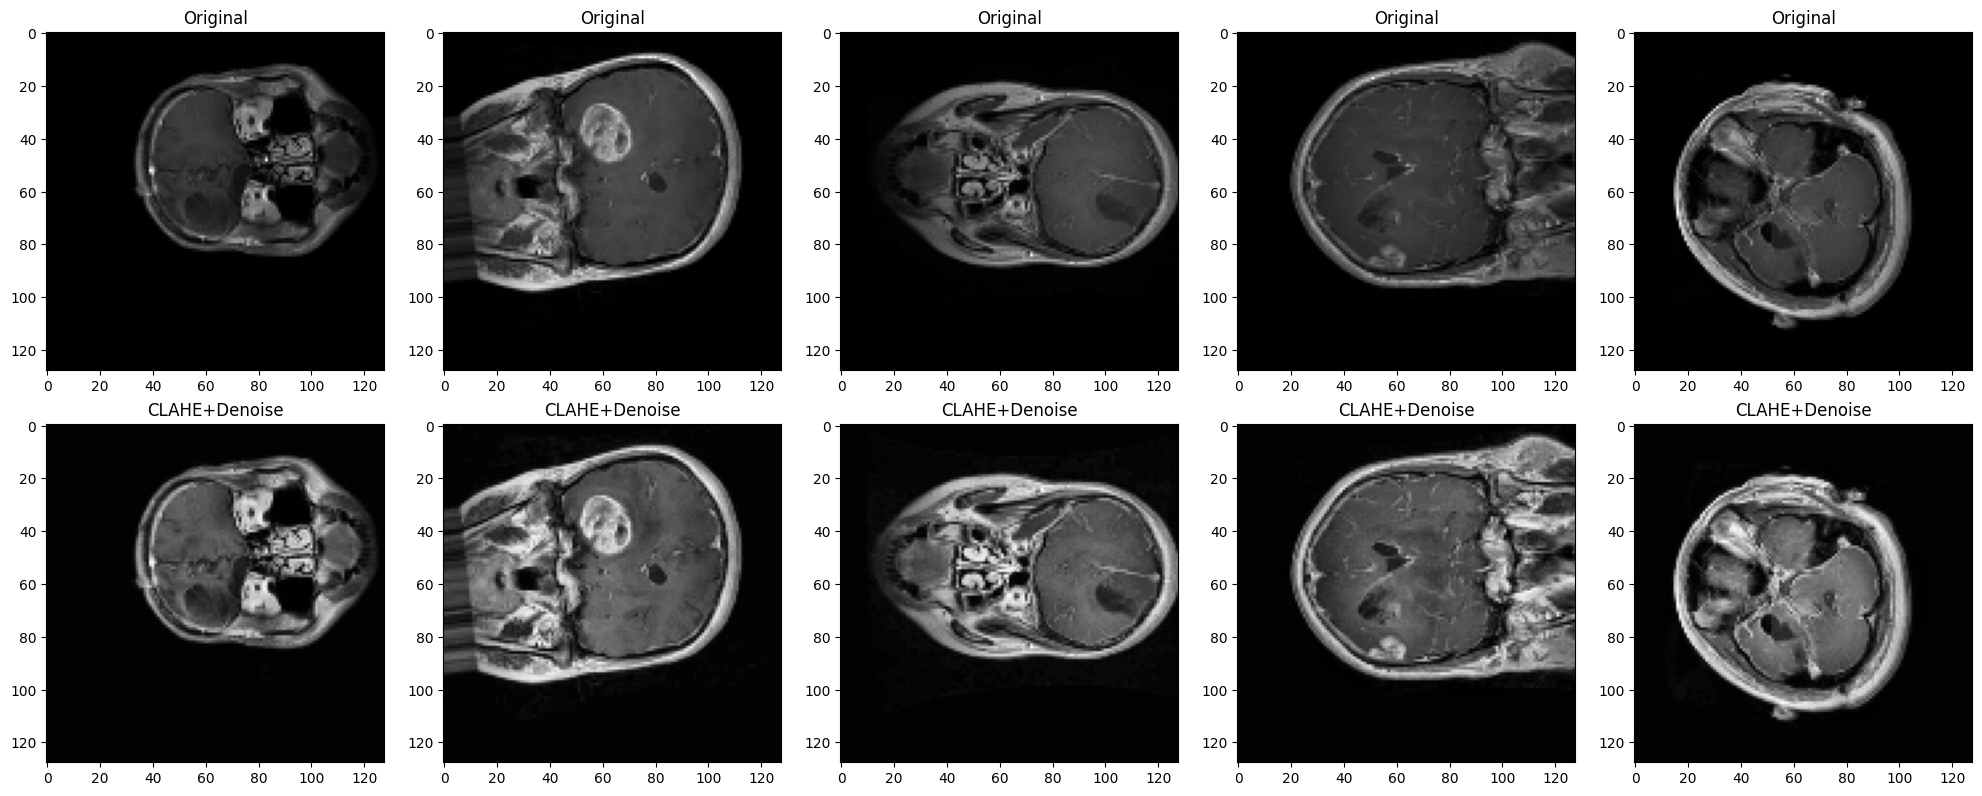

Sample contrast: Original std=0.163 → Enhanced 0.230 (+41.4%)


In [13]:
sample_paths = glob(f"{root_dir}**/*.jpg", recursive=True)[:20]

fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, path in enumerate(sample_paths[:5]):
    orig = preprocess_image(path)
    enh = preprocess_image_enhanced(path)
    axs[0,i].imshow(orig, cmap='gray'); axs[0,i].set_title('Original')
    axs[1,i].imshow(enh, cmap='gray'); axs[1,i].set_title('CLAHE+Denoise')
plt.tight_layout()
plt.savefig('clahe_test.png', dpi=150)
plt.show()

orig_std = np.std(orig)
enh_std = np.std(enh)
print(f"Sample contrast: Original std={orig_std:.3f} \u2192 Enhanced {enh_std:.3f} (+{((enh_std-orig_std)/orig_std)*100:.1f}%)")

# 8. Process Datasets to NPZ
- **Flexible**: `proc_func` param → Original + Enhanced.
- Saves 4 NPZs (~900MB compressed): train/test × original/enhanced.
- Same exact split for fair comparison.

In [14]:
def process_to_npz(paths, y, output_file, proc_func=preprocess_image, size=(128,128), max_samples=None):
    X, labels = [], []
    paths_use = paths[:max_samples] if max_samples else paths
    print(f"Processing {len(paths_use)} images to {output_file}")
    for path, lbl in tqdm(zip(paths_use, y), total=len(paths_use)):
        proc = proc_func(path)
        if proc is not None:
            X.append(proc[:, :, np.newaxis])
            labels.append(lbl)
    X = np.array(X, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    np.savez_compressed(output_file, X=X, y=labels, classes=classes, class_map=class_map)
    print(f"✅ Saved {output_file}: X{X.shape}, y{labels.shape}, balance {np.bincount(labels)}")
    return X, labels

print("\n=== PROCESSING ORIGINAL ===")
X_train_orig, y_train_orig = process_to_npz(paths_train, y_train, 'processed_train.npy')
X_test_orig, y_test_orig = process_to_npz(paths_test, y_test, 'processed_test.npy')

print("\n=== PROCESSING ENHANCED ===")
X_train_enh, y_train_enh = process_to_npz(paths_train, y_train, 'processed_train_enhanced.npy', proc_func=preprocess_image_enhanced)
X_test_enh, y_test_enh = process_to_npz(paths_test, y_test, 'processed_test_enhanced.npy', proc_func=preprocess_image_enhanced)





=== PROCESSING ORIGINAL ===
Processing 9689 images to processed_train.npy


  0%|          | 0/9689 [00:00<?, ?it/s]

✅ Saved processed_train.npy: X(9689, 128, 128, 1), y(9689,), balance [3206 3206 3277]
Processing 2423 images to processed_test.npy


  0%|          | 0/2423 [00:00<?, ?it/s]

✅ Saved processed_test.npy: X(2423, 128, 128, 1), y(2423,), balance [802 802 819]

=== PROCESSING ENHANCED ===
Processing 9689 images to processed_train_enhanced.npy


  0%|          | 0/9689 [00:00<?, ?it/s]

✅ Saved processed_train_enhanced.npy: X(9689, 128, 128, 1), y(9689,), balance [3206 3206 3277]
Processing 2423 images to processed_test_enhanced.npy


  0%|          | 0/2423 [00:00<?, ?it/s]

✅ Saved processed_test_enhanced.npy: X(2423, 128, 128, 1), y(2423,), balance [802 802 819]


# 9. Final Validation, Balance Charts & Sample Grid
- **Load enhanced NPZs** → Verify shapes/range/balance/dtype.
- **Class distribution table** → Per-class train/test counts + split ratio (~80/20 stratified).
- **Train/Test bar charts** → `balance.png` (visual confirmation).
- **Sample images grid** (2 per class from enhanced train) → `sample_grid.png` (glioma/menin/tumor visuals).

── Shape checks ──────────────────────
Train : X(9689, 128, 128, 1)  y(9689,)
Test  : X(2423, 128, 128, 1)  y(2423,)
Dtype : float32  (expected float32)
Range : [0.000 – 1.000]  (expected 0–1)

── Class distribution ────────────────
  brain_glioma          train=3206  test=802  (25% split)
  brain_menin           train=3206  test=802  (25% split)
  brain_tumor           train=3277  test=819  (25% split)


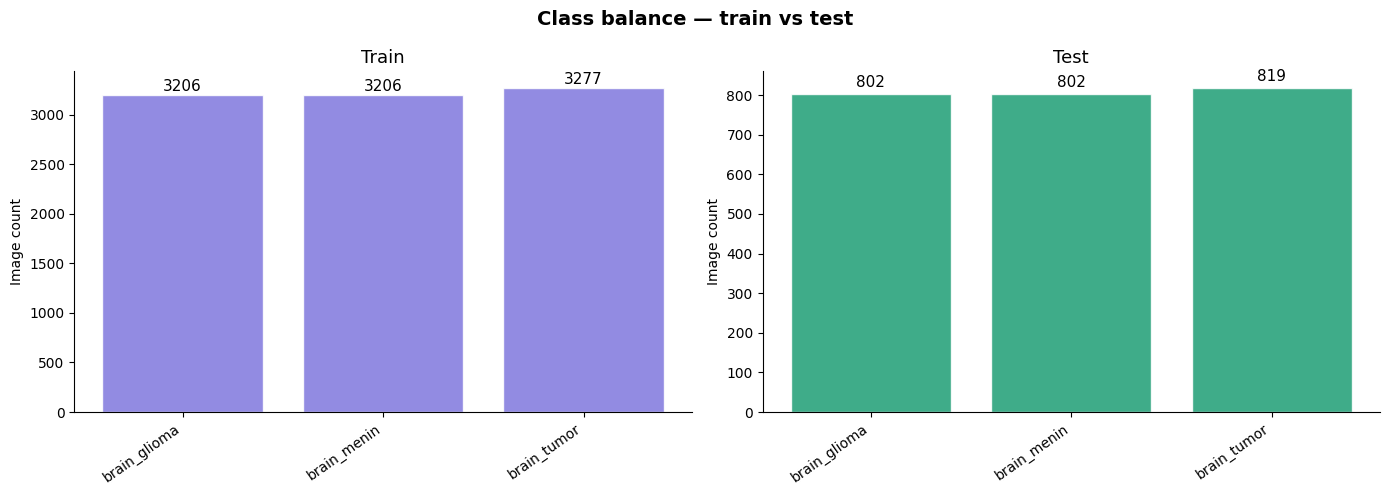


balance.png saved


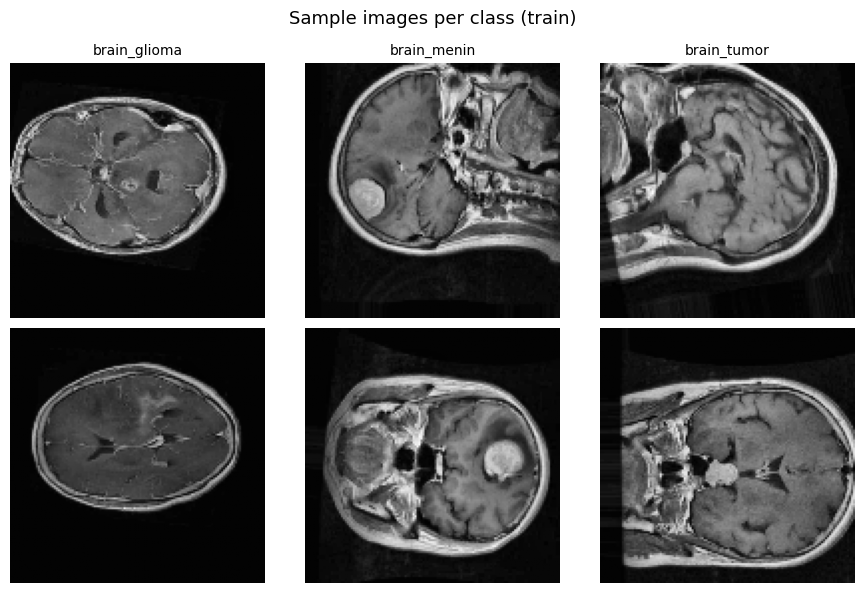

sample_grid.png saved.


In [15]:
data_tr = np.load('processed_train_enhanced.npy.npz', allow_pickle=True)
data_te = np.load('processed_test_enhanced.npy.npz',  allow_pickle=True)

X_tr, y_tr = data_tr['X'], data_tr['y']
X_te, y_te = data_te['X'], data_te['y']
classes    = list(data_tr['classes'])

# 2. Shape + range checks
print("── Shape checks ──────────────────────")
print(f"Train : X{X_tr.shape}  y{y_tr.shape}")
print(f"Test  : X{X_te.shape}  y{y_te.shape}")
print(f"Dtype : {X_tr.dtype}  (expected float32)")
print(f"Range : [{X_tr.min():.3f} – {X_tr.max():.3f}]  (expected 0–1)")

# 3. Per-class counts
tr_counts = np.bincount(y_tr)
te_counts = np.bincount(y_te)
print("\n── Class distribution ────────────────")
for i, cls in enumerate(classes):
    ratio = te_counts[i] / tr_counts[i] * 100
    print(f"  {cls:20s}  train={tr_counts[i]:4d}  test={te_counts[i]:3d}  ({ratio:.0f}% split)")

# 4. Bar charts — train vs test side by side
x     = np.arange(len(classes))
width = 0.38
colors = ['#7F77DD', '#1D9E75']

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class balance — train vs test', fontsize=14, fontweight='bold')

for ax, counts, split, color in zip(
        axs, [tr_counts, te_counts],
        ['Train', 'Test'], colors):
    bars = ax.bar(x, counts, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(split, fontsize=13)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=35, ha='right')
    ax.set_ylabel('Image count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(n), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nbalance.png saved")

# 5. Sample-image sanity grid (2 per class)
n_cls = len(classes)
fig2, axs2 = plt.subplots(2, n_cls, figsize=(3*n_cls, 6))
for c, cls in enumerate(classes):
    idx = np.where(y_tr == c)[0][:2]
    for row, i in enumerate(idx):
        axs2[row, c].imshow(X_tr[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        axs2[row, c].set_title(cls if row == 0 else '', fontsize=10)
        axs2[row, c].axis('off')
fig2.suptitle('Sample images per class (train)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("sample_grid.png saved.")